<a href="https://colab.research.google.com/github/fifanuurunhalizah09/PCVK_Ganjil2026/blob/main/Week5_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import platform
import hashlib
import datetime
import zoneinfo

NAMA = 'Fifa Nuurun Halizah'
NIM = '244107020019'
N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s :' % k, v)

print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')

NAMA : Fifa Nuurun Halizah
NIM : 244107020019 | N = 19
bins   : 64
clip   : 3.0
tile   : 5
L      : 4
WAKTU : 2026-10-02 10:37:46 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving lena.jpg to lena (1).jpg


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

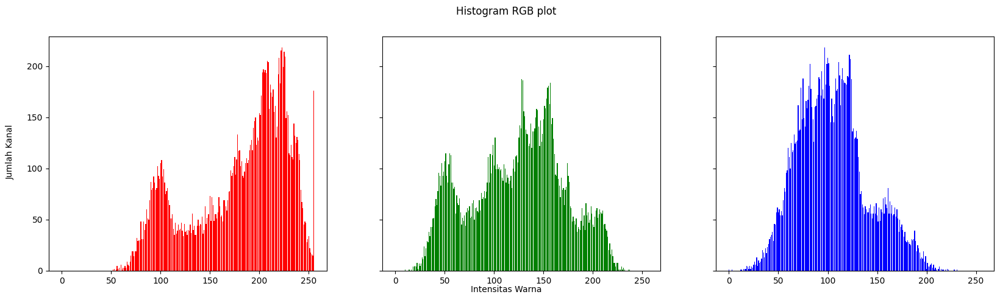

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)

names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)

fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)

fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kanal', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving KTM1d.jpg to KTM1d (1).jpg
Saving KTM1c.jpg to KTM1c.jpg
Saving KTM1b.jpg to KTM1b.jpg
Saving KTM1a.jpg to KTM1a (1).jpg


In [ ]:
import os

print(os.listdir())

['.config', 'lena.jpg', 'KTM1d.jpg', 'KTM1a (1).jpg', 'KTM1a.jpg', 'KTM1d (1).jpg', 'drive', 'lena_lc.jpg', 'manual_KTM1a.jpg', 'cv2_KTM1a.jpg', 'manual_lena_lc.jpg', 'KTM1c.jpg', 'KTM1b.jpg', 'lena (1).jpg', 'cv2_lena_lc.jpg', 'sample_data']


=== Perbandingan Histogram LENA ===
Manual vs NumPy
Red   : 0
Green : 0
Blue  : 0

Manual vs cv.calcHist
Red   : 0.0
Green : 0.0
Blue  : 0.0


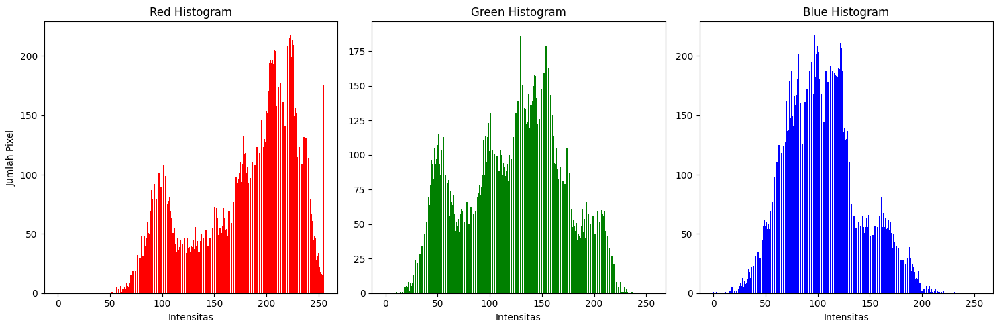

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar lena
img = cv.imread('lena.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# =========================
# 1. Histogram Manual
# =========================

red_manual = [0] * 256
green_manual = [0] * 256
blue_manual = [0] * 256

height, width, _ = img_rgb.shape

for y in range(height):
    for x in range(width):
        red_manual[img_rgb[y][x][0]] += 1
        green_manual[img_rgb[y][x][1]] += 1
        blue_manual[img_rgb[y][x][2]] += 1


# =========================
# 2. NumPy Histogram
# =========================

red_np, _ = np.histogram(img_rgb[:, :, 0], bins=256, range=(0, 256))
green_np, _ = np.histogram(img_rgb[:, :, 1], bins=256, range=(0, 256))
blue_np, _ = np.histogram(img_rgb[:, :, 2], bins=256, range=(0, 256))


# =========================
# 3. cv.calcHist
# =========================

red_cv = cv.calcHist([img_rgb], [0], None, [256], [0, 256]).flatten()
green_cv = cv.calcHist([img_rgb], [1], None, [256], [0, 256]).flatten()
blue_cv = cv.calcHist([img_rgb], [2], None, [256], [0, 256]).flatten()


# =========================
# Menghitung Selisih Maksimum
# =========================

selisih_red_np = np.max(np.abs(np.array(red_manual) - red_np))
selisih_green_np = np.max(np.abs(np.array(green_manual) - green_np))
selisih_blue_np = np.max(np.abs(np.array(blue_manual) - blue_np))

selisih_red_cv = np.max(np.abs(np.array(red_manual) - red_cv))
selisih_green_cv = np.max(np.abs(np.array(green_manual) - green_cv))
selisih_blue_cv = np.max(np.abs(np.array(blue_manual) - blue_cv))


print("=== Perbandingan Histogram LENA ===")
print("Manual vs NumPy")
print("Red   :", selisih_red_np)
print("Green :", selisih_green_np)
print("Blue  :", selisih_blue_np)

print("\nManual vs cv.calcHist")
print("Red   :", selisih_red_cv)
print("Green :", selisih_green_cv)
print("Blue  :", selisih_blue_cv)


# =========================
# Menampilkan Histogram
# =========================

x = np.arange(256)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(x, red_manual, color='red')
plt.title('Red Histogram')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.subplot(1, 3, 2)
plt.bar(x, green_manual, color='green')
plt.title('Green Histogram')
plt.xlabel('Intensitas')

plt.subplot(1, 3, 3)
plt.bar(x, blue_manual, color='blue')
plt.title('Blue Histogram')
plt.xlabel('Intensitas')

plt.tight_layout()
plt.show()

=== Perbandingan Histogram KTM1b ===
Manual vs NumPy
Red   : 0
Green : 0
Blue  : 0

Manual vs cv.calcHist
Red   : 0.0
Green : 0.0
Blue  : 0.0


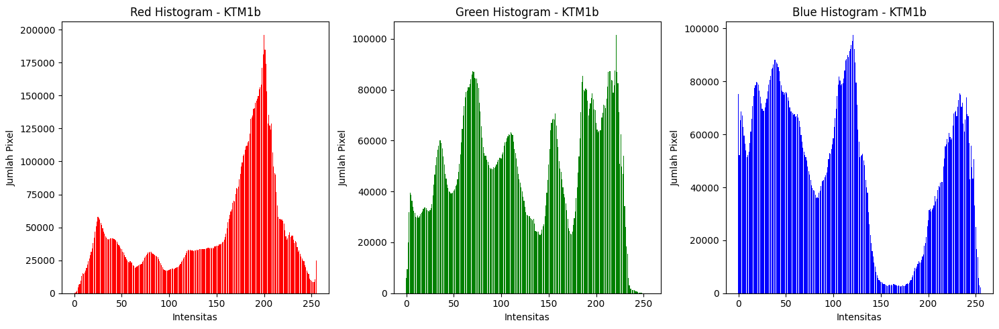

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar KTM1b
img = cv.imread('KTM1b.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Histogram manual
red_manual = [0] * 256
green_manual = [0] * 256
blue_manual = [0] * 256

height, width, _ = img_rgb.shape

for y in range(height):
    for x in range(width):
        red_manual[img_rgb[y][x][0]] += 1
        green_manual[img_rgb[y][x][1]] += 1
        blue_manual[img_rgb[y][x][2]] += 1

# NumPy
red_np, _ = np.histogram(img_rgb[:, :, 0], bins=256, range=(0, 256))
green_np, _ = np.histogram(img_rgb[:, :, 1], bins=256, range=(0, 256))
blue_np, _ = np.histogram(img_rgb[:, :, 2], bins=256, range=(0, 256))

# cv.calcHist
red_cv = cv.calcHist([img_rgb], [0], None, [256], [0, 256]).flatten()
green_cv = cv.calcHist([img_rgb], [1], None, [256], [0, 256]).flatten()
blue_cv = cv.calcHist([img_rgb], [2], None, [256], [0, 256]).flatten()

# Menampilkan selisih maksimum
print("=== Perbandingan Histogram KTM1b ===")

print("Manual vs NumPy")
print("Red   :", np.max(np.abs(np.array(red_manual) - red_np)))
print("Green :", np.max(np.abs(np.array(green_manual) - green_np)))
print("Blue  :", np.max(np.abs(np.array(blue_manual) - blue_np)))

print("\nManual vs cv.calcHist")
print("Red   :", np.max(np.abs(np.array(red_manual) - red_cv)))
print("Green :", np.max(np.abs(np.array(green_manual) - green_cv)))
print("Blue  :", np.max(np.abs(np.array(blue_manual) - blue_cv)))

# =========================
# Grafik Histogram KTM1b
# =========================

x = np.arange(256)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.bar(x, red_manual, color='red')
plt.title('Red Histogram - KTM1b')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.subplot(1, 3, 2)
plt.bar(x, green_manual, color='green')
plt.title('Green Histogram - KTM1b')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.subplot(1, 3, 3)
plt.bar(x, blue_manual, color='blue')
plt.title('Blue Histogram - KTM1b')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

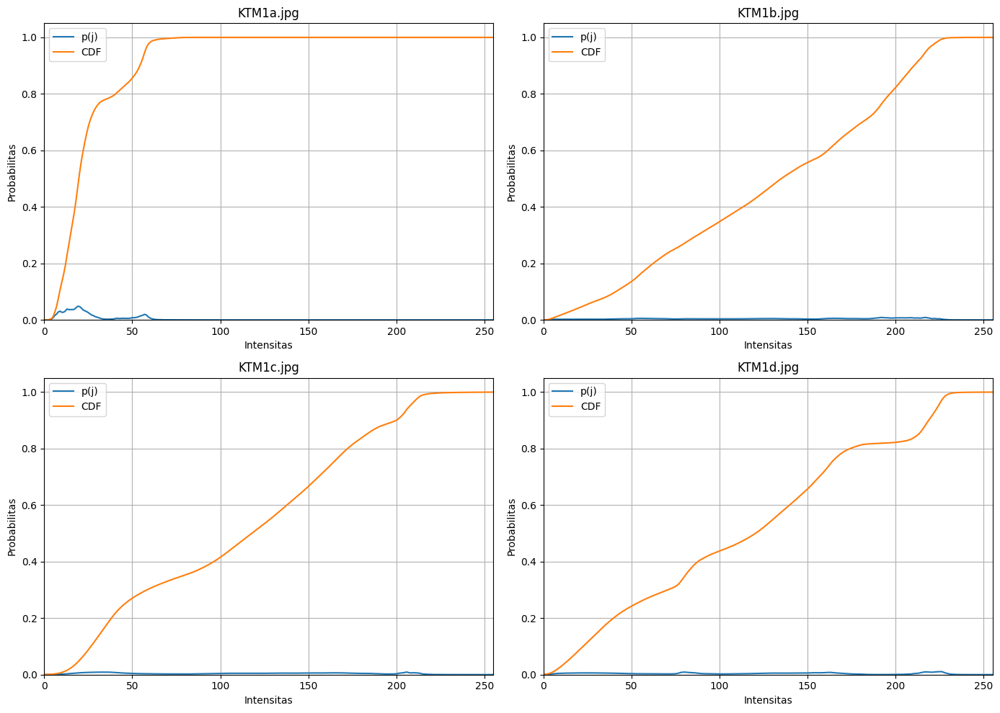

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Nama file KTM
files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']

plt.figure(figsize=(14, 10))

for i, filename in enumerate(files):

    # Membaca gambar grayscale
    img = cv.imread(filename, cv.IMREAD_GRAYSCALE)

    # Histogram 256 bin
    hist, bins = np.histogram(img.flatten(), bins=256, range=(0, 256))

    # Histogram ternormalisasi p(j)
    p = hist / hist.sum()

    # CDF
    cdf = np.cumsum(p)

    # Plot
    plt.subplot(2, 2, i + 1)

    plt.plot(p, label='p(j)')
    plt.plot(cdf, label='CDF')

    plt.title(filename)
    plt.xlabel('Intensitas')
    plt.ylabel('Probabilitas')
    plt.xlim(0, 255)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

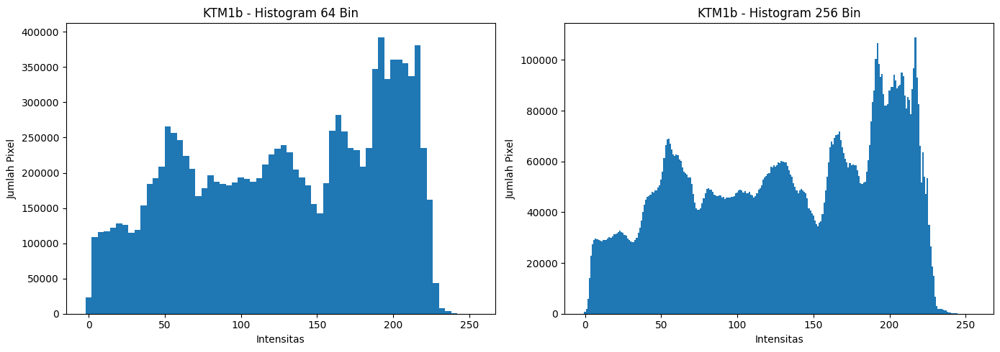

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca KTM1b
img = cv.imread('KTM1b.jpg', cv.IMREAD_GRAYSCALE)

# Parameter sesuai NIM
PARAM = {
    'bins': 64
}

# Histogram dengan PARAM['bins'] = 64
hist_64, bins_64 = np.histogram(
    img.flatten(),
    bins=PARAM['bins'],
    range=(0, 256)
)

# Histogram dengan 256 bin
hist_256, bins_256 = np.histogram(
    img.flatten(),
    bins=256,
    range=(0, 256)
)

# Menampilkan keduanya berdampingan
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(bins_64[:-1], hist_64, width=256/PARAM['bins'])
plt.title('KTM1b - Histogram 64 Bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.subplot(1, 2, 2)
plt.bar(bins_256[:-1], hist_256, width=1)
plt.title('KTM1b - Histogram 256 Bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving lena_lc.jpg to lena_lc (1).jpg


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
img = cv.imread('lena_lc.jpg')

print('Ukuran gambar:', img.shape)

Ukuran gambar: (250, 257, 3)


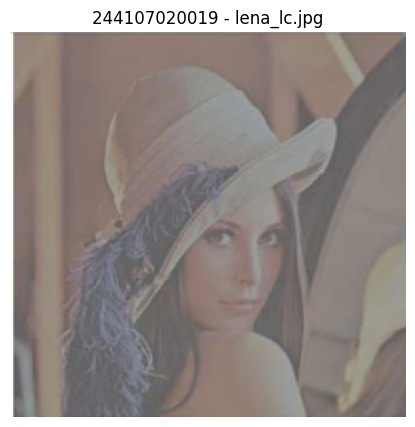

In [ ]:
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(6, 5))
plt.imshow(img_rgb)
plt.title(NIM + ' - lena_lc.jpg')
plt.axis('off')
plt.show()

In [ ]:
def histogram_equalization_manual(gray):
    # 1. Hitung histogram
    hist = np.zeros(256, dtype=np.int64)

    for y in range(gray.shape[0]):
        for x in range(gray.shape[1]):
            hist[gray[y, x]] += 1

    # 2. Hitung probabilitas
    p = hist / gray.size

    # 3. Hitung CDF
    cdf = np.cumsum(p)

    # 4. Buat tabel transformasi
    cdf_min = cdf[cdf > 0].min()
    transform = ((cdf - cdf_min) / (1 - cdf_min) * 255)

    transform = np.round(transform).astype(np.uint8)

    # 5. Transformasi setiap piksel
    hasil = transform[gray]

    return hasil

In [ ]:
lena = cv.imread('lena_lc.jpg', cv.IMREAD_GRAYSCALE)

lena_manual = histogram_equalization_manual(lena)
lena_cv = cv.equalizeHist(lena)

In [ ]:
import cv2 as cv
import numpy as np

# 1. Baca citra terlebih dahulu agar variabel img_lena_lc terdefinisi
img_lena_lc = cv.imread('lena_lc.jpg')

# Pastikan file lena_lc.jpg berhasil terbaca
if img_lena_lc is None:
    raise FileNotFoundError("File 'lena_lc.jpg' tidak ditemukan. Pastikan file berada di folder yang sama!")

# 2. Ekualisasi per kanal warna B, G, R dengan OpenCV
b, g, r = cv.split(img_lena_lc)

b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)

img_lena_cv2 = cv.merge([b_eq, g_eq, r_eq])

# 3. Penerapan fungsi manual ke tiap kanal B, G, R
b_man = histogram_equalization_manual(b)
g_man = histogram_equalization_manual(g)
r_man = histogram_equalization_manual(r)
img_lena_eq = cv.merge([b_man, g_man, r_man])

# 4. Menghitung selisih maksimum antara manual dan cv.equalizeHist
diff = np.abs(img_lena_eq.astype(np.int16) - img_lena_cv2.astype(np.int16))
max_diff = np.max(diff)

print(f"Selisih maksimum antara manual dan cv2: {max_diff}")

Selisih maksimum antara manual dan cv2: 0


/tmp/ipykernel_1544/3677959371.py:33: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_lena_lc[:, :, i].ravel(), 256, [0, 256], color=col)
/tmp/ipykernel_1544/3677959371.py:39: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_lena_cv2[:, :, i].ravel(), 256, [0, 256], color=col)


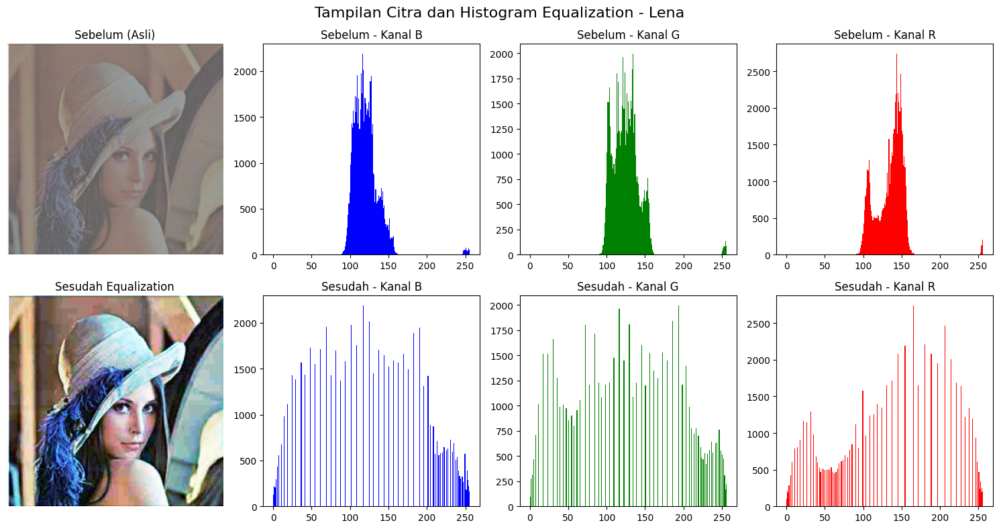

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Olah citra Lena
img_lena_lc = cv.imread('lena_lc.jpg')

# Ekualisasi BGR
b, g, r = cv.split(img_lena_lc)
b_eq = cv.equalizeHist(b)
g_eq = cv.equalizeHist(g)
r_eq = cv.equalizeHist(r)
img_lena_cv2 = cv.merge([b_eq, g_eq, r_eq])

# 2. Buat Plot Terpadu (Gambar + Histogram)
plt.figure(figsize=(15, 8))

# --- Gambar Sebelum ---
plt.subplot(2, 4, 1)
plt.imshow(cv.cvtColor(img_lena_lc, cv.COLOR_BGR2RGB))
plt.title('Sebelum (Asli)')
plt.axis('off')

# --- Gambar Sesudah ---
plt.subplot(2, 4, 5)
plt.imshow(cv.cvtColor(img_lena_cv2, cv.COLOR_BGR2RGB))
plt.title('Sesudah Equalization')
plt.axis('off')

# --- Histogram Sebelum (B, G, R) ---
colors = ('b', 'g', 'r')
for i, col in enumerate(colors):
    plt.subplot(2, 4, i + 2)
    plt.hist(img_lena_lc[:, :, i].ravel(), 256, [0, 256], color=col)
    plt.title(f'Sebelum - Kanal {col.upper()}')

# --- Histogram Sesudah (B, G, R) ---
for i, col in enumerate(colors):
    plt.subplot(2, 4, i + 6)
    plt.hist(img_lena_cv2[:, :, i].ravel(), 256, [0, 256], color=col)
    plt.title(f'Sesudah - Kanal {col.upper()}')

plt.suptitle('Tampilan Citra dan Histogram Equalization - Lena', fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1544/3101366400.py:33: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_ktm[:, :, i].ravel(), 256, [0, 256], color=col)
/tmp/ipykernel_1544/3101366400.py:39: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_ktm_cv2[:, :, i].ravel(), 256, [0, 256], color=col)


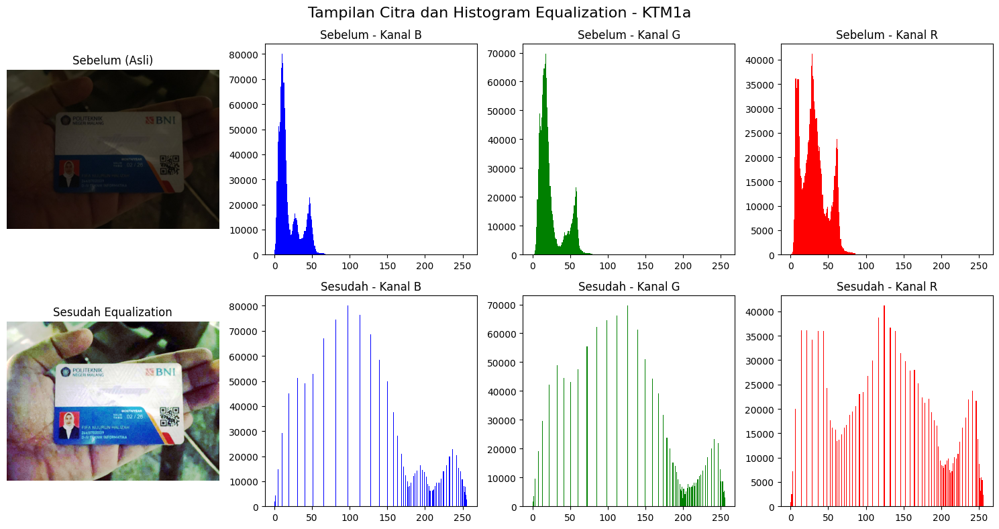

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

# 1. Olah citra KTM1a
img_ktm = cv.imread('KTM1a.jpg')

# Ekualisasi BGR
b, g, r = cv.split(img_ktm)
b_eq = cv.equalizeHist(b)[cite: 2]
g_eq = cv.equalizeHist(g)[cite: 2]
r_eq = cv.equalizeHist(r)[cite: 2]
img_ktm_cv2 = cv.merge([b_eq, g_eq, r_eq])

# 2. Buat Plot Terpadu (Gambar + Histogram)
plt.figure(figsize=(15, 8))

# --- Gambar Sebelum ---
plt.subplot(2, 4, 1)
plt.imshow(cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB))
plt.title('Sebelum (Asli)')
plt.axis('off')

# --- Gambar Sesudah ---
plt.subplot(2, 4, 5)
plt.imshow(cv.cvtColor(img_ktm_cv2, cv.COLOR_BGR2RGB))
plt.title('Sesudah Equalization')
plt.axis('off')

# --- Histogram Sebelum (B, G, R) ---
colors = ('b', 'g', 'r')
for i, col in enumerate(colors):
    plt.subplot(2, 4, i + 2)
    plt.hist(img_ktm[:, :, i].ravel(), 256, [0, 256], color=col)
    plt.title(f'Sebelum - Kanal {col.upper()}')

# --- Histogram Sesudah (B, G, R) ---
for i, col in enumerate(colors):
    plt.subplot(2, 4, i + 6)
    plt.hist(img_ktm_cv2[:, :, i].ravel(), 256, [0, 256], color=col)
    plt.title(f'Sesudah - Kanal {col.upper()}')

plt.suptitle('Tampilan Citra dan Histogram Equalization - KTM1a', fontsize=16)
plt.tight_layout()
plt.show()

Selisih maksimum manual vs cv.equalizeHist (lena_lc): 0


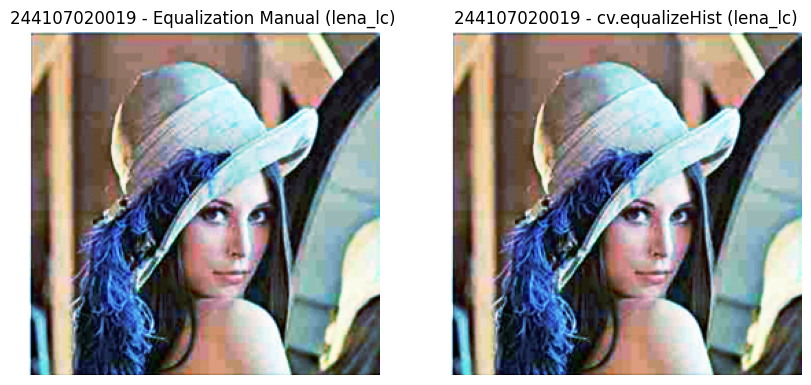

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca citra lena_lc.jpg
bgr = cv.imread('lena_lc.jpg')

# Cek ekstensi lain jika .jpg tidak ditemukan
if bgr is None:
    bgr = cv.imread('lena_lc.jpeg')

if bgr is None:
    raise FileNotFoundError("File 'lena_lc.jpg' tidak ditemukan! Pastikan file sudah di-upload.")

# 2. Process Equalization Manual per kanal
b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

# 3. Process Equalization OpenCV (cv.equalizeHist) per kanal
b, g, r = cv.split(bgr)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)
hasil_cv = cv.merge([b_equalized, g_equalized, r_equalized])

# 4. Hitung Selisih Maksimum
selisih = np.max(np.abs(hasil_eq.astype(np.int16) - hasil_cv.astype(np.int16)))
print('Selisih maksimum manual vs cv.equalizeHist (lena_lc):', selisih)

# 5. Tampilkan Hasil Gambar (Variabel NIM langsung dipakai dari cell awal)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB))
plt.title(f"{NIM} - Equalization Manual (lena_lc)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(hasil_cv, cv.COLOR_BGR2RGB))
plt.title(f"{NIM} - cv.equalizeHist (lena_lc)")
plt.axis('off')

plt.show()

Selisih maksimum manual vs cv.equalizeHist (KTM1a): 0


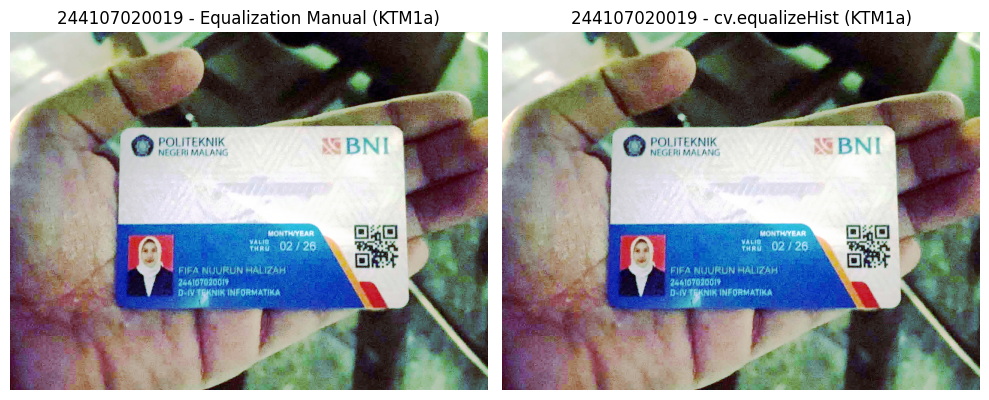

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca citra KTM1a.jpg
bgr = cv.imread('KTM1a.jpg')

# Cek ekstensi lain jika .jpg tidak ditemukan
if bgr is None:
    bgr = cv.imread('KTM1a.jpeg')

if bgr is None:
    bgr = cv.imread('KTM1a.png')

if bgr is None:
    raise FileNotFoundError("File 'KTM1a.jpg' tidak ditemukan! Pastikan file sudah di-upload.")

# 2. Process Equalization Manual per kanal
b, g, r = cv.split(bgr)
b_eq = histogram_equalization_manual(b)
g_eq = histogram_equalization_manual(g)
r_eq = histogram_equalization_manual(r)
hasil_eq = cv.merge([b_eq, g_eq, r_eq])

# 3. Process Equalization OpenCV (cv.equalizeHist) per kanal
b, g, r = cv.split(bgr)
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)
hasil_cv = cv.merge([b_equalized, g_equalized, r_equalized])

# 4. Hitung Selisih Maksimum
selisih = np.max(np.abs(hasil_eq.astype(np.int16) - hasil_cv.astype(np.int16)))
print('Selisih maksimum manual vs cv.equalizeHist (KTM1a):', selisih)

# 5. Tampilkan Hasil Gambar (Variabel NIM langsung dipakai dari cell awal)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(hasil_eq, cv.COLOR_BGR2RGB))
plt.title(f"{NIM} - Equalization Manual (KTM1a)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(hasil_cv, cv.COLOR_BGR2RGB))
plt.title(f"{NIM} - cv.equalizeHist (KTM1a)")
plt.axis('off')

plt.tight_layout()
plt.show()

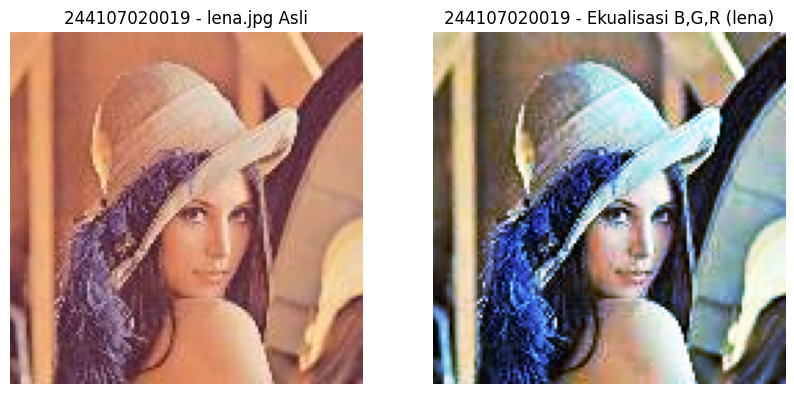

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Tentukan path file langsung (atau ganti sesuai lokasi file kamu)
berkas = 'lena.jpg'
bgr = cv.imread(berkas)

if bgr is None:
    raise FileNotFoundError(f"File tidak ditemukan di {berkas}. Cek kembali nama file dan foldernya.")

# Cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - lena.jpg Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Ekualisasi B,G,R (lena)')
plt.axis('off')

plt.show()

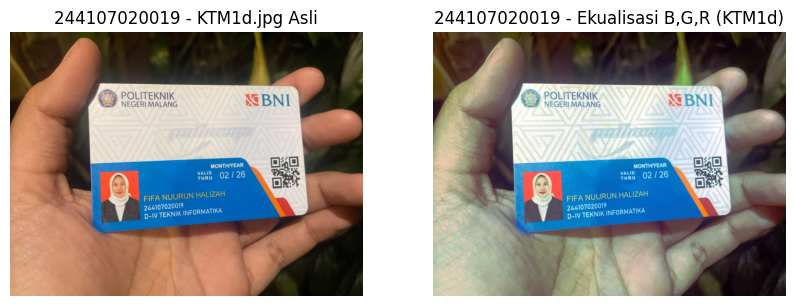

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Tentukan path file untuk KTM1d.jpg
berkas = 'KTM1d.jpg'
bgr = cv.imread(berkas)

if bgr is None:
    raise FileNotFoundError(f"File tidak ditemukan di {berkas}. Cek kembali nama file dan foldernya.")

# Cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1d.jpg Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Ekualisasi B,G,R (KTM1d)')
plt.axis('off')

plt.show()

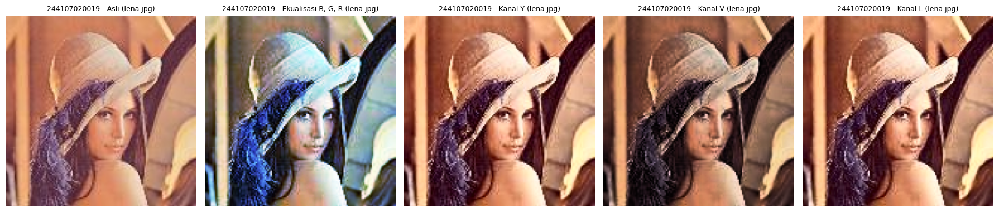

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# --- TAHAP 1: lena.jpg ---
berkas_lena = 'lena.jpg'
bgr_lena = cv.imread(berkas_lena)

if bgr_lena is None:
    bgr_lena = cv.imread('lena.jpg.jpeg')

if bgr_lena is None:
    raise FileNotFoundError("File 'lena.jpg' tidak ditemukan! Pastikan file sudah di-upload.")

# Cara 1: Tiap kanal B, G, R diekualisasi sendiri-sendiri
kanal_lena = list(cv.split(bgr_lena))
for i in range(3):
    kanal_lena[i] = cv.equalizeHist(kanal_lena[i])
he_rgb_lena = cv.merge(kanal_lena)

# Cara 2: Hanya kanal terang yang diekualisasi
# Ruang warna YCrCb (Kanal Y)
ycrcb_lena = cv.cvtColor(bgr_lena, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb_lena)
he_y_lena = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# Ruang warna HSV (Kanal V)
hsv_lena = cv.cvtColor(bgr_lena, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv_lena)
he_v_lena = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# Ruang warna LAB (Kanal L)
lab_lena = cv.cvtColor(bgr_lena, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab_lena)
he_l_lena = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

# Visualisasi
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra_lena = [bgr_lena, he_rgb_lena, he_y_lena, he_v_lena, he_l_lena]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra_lena, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t + ' (lena.jpg)', fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

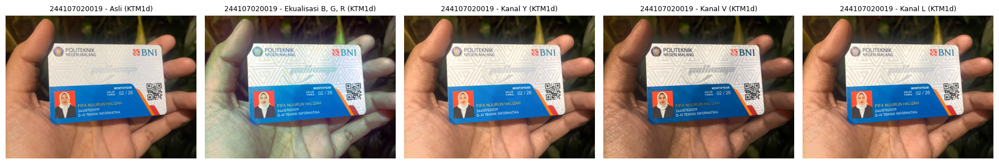

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# --- TAHAP 2: KTM1d.jpg ---
berkas_ktm = 'KTM1d.jpg'
bgr_ktm = cv.imread(berkas_ktm)

if bgr_ktm is None:
    raise FileNotFoundError("File 'KTM1d.jpg' tidak ditemukan! Pastikan file sudah di-upload.")

# Cara 1: Tiap kanal B, G, R diekualisasi sendiri-sendiri
kanal_ktm = list(cv.split(bgr_ktm))
for i in range(3):
    kanal_ktm[i] = cv.equalizeHist(kanal_ktm[i])
he_rgb_ktm = cv.merge(kanal_ktm)

# Cara 2: Hanya kanal terang yang diekualisasi
# Ruang warna YCrCb (Kanal Y)
ycrcb_ktm = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb_ktm)
he_y_ktm = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# Ruang warna HSV (Kanal V)
hsv_ktm = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv_ktm)
he_v_ktm = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# Ruang warna LAB (Kanal L)
lab_ktm = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab_ktm)
he_l_ktm = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

# Visualisasi
judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra_ktm = [bgr_ktm, he_rgb_ktm, he_y_ktm, he_v_ktm, he_l_ktm]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra_ktm, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t + ' (KTM1d)', fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Parameter sesuai notebook kamu: clip = 3.0, tile = 5
clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(5, 5))

# CLAHE pada Kanal V (HSV)
hsv_clahe = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv_clahe)
v_clahe = clahe.apply(v)
he_v_clahe = cv.cvtColor(cv.merge([h, s, v_clahe]), cv.COLOR_HSV2BGR)

=== PERBANDINGAN METRIK (KTM1d) ===
Ekualisasi Biasa (Kanal V) -> Pergeseran Hue: 0.9200000166893005° | Rerata Kecerahan: 128.27
CLAHE (Kanal V)            -> Pergeseran Hue: 0.6000000238418579° | Rerata Kecerahan: 140.04


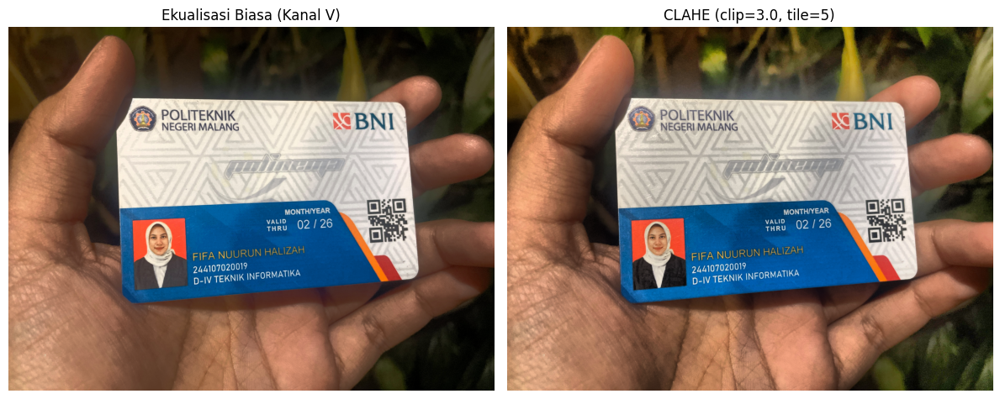

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar KTM1d.jpg
bgr_ktm = cv.imread('KTM1d.jpg')

# 2. Ekualisasi Biasa pada Kanal V (HSV)
hsv_biasa = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2HSV)
h_b, s_b, v_b = cv.split(hsv_biasa)
he_v_biasa = cv.cvtColor(cv.merge([h_b, s_b, cv.equalizeHist(v_b)]), cv.COLOR_HSV2BGR)

# 3. CLAHE pada Kanal V (HSV) - Nilai langsung diisi sesuai NIM kamu (clip=3.0, tile=5)
clahe = cv.createCLAHE(clipLimit=3.0, tileGridSize=(5, 5))
hsv_clahe = cv.cvtColor(bgr_ktm, cv.COLOR_BGR2HSV)
h_c, s_c, v_c = cv.split(hsv_clahe)
v_clahe = clahe.apply(v_c)
he_v_clahe = cv.cvtColor(cv.merge([h_c, s_c, v_clahe]), cv.COLOR_HSV2BGR)

# 4. Fungsi Hitung Metrik
def hitung_metrik(img_asli, img_hasil):
    h_asli = cv.cvtColor(img_asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.float32) * 2
    h_hasil = cv.cvtColor(img_hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.float32) * 2
    diff = np.abs(h_asli - h_hasil)
    diff = np.minimum(diff, 360 - diff)
    shift_hue = np.mean(diff)

    v_hasil = cv.cvtColor(img_hasil, cv.COLOR_BGR2HSV)[:, :, 2]
    rerata_kecerahan = np.mean(v_hasil)
    return round(shift_hue, 2), round(rerata_kecerahan, 2)

# Hitung Metrik
hue_biasa, bright_biasa = hitung_metrik(bgr_ktm, he_v_biasa)
hue_clahe, bright_clahe = hitung_metrik(bgr_ktm, he_v_clahe)

# 5. Cetak Hasil Angka
print("=== PERBANDINGAN METRIK (KTM1d) ===")
print(f"Ekualisasi Biasa (Kanal V) -> Pergeseran Hue: {hue_biasa}° | Rerata Kecerahan: {bright_biasa}")
print(f"CLAHE (Kanal V)            -> Pergeseran Hue: {hue_clahe}° | Rerata Kecerahan: {bright_clahe}")

# 6. Tampilkan Gambar Berdampingan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(he_v_biasa, cv.COLOR_BGR2RGB))
plt.title("Ekualisasi Biasa (Kanal V)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_v_clahe, cv.COLOR_BGR2RGB))
plt.title("CLAHE (clip=3.0, tile=5)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Parameter dari NIM
clip_val = 3.0
tile_val = 5

# Baca citra grayscale
img = cv.imread('KTM1a.jpg', cv.IMREAD_GRAYSCALE)

Nilai PSNR (Citra Asli vs cv.equalizeHist): 6.50 dB


/tmp/ipykernel_1544/1957543644.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256], color='black')
/tmp/ipykernel_1544/1957543644.py:39: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_manual.ravel(), 256, [0, 256], color='blue')
/tmp/ipykernel_1544/1957543644.py:43: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_eq.ravel(), 256, [0, 256], color='red')


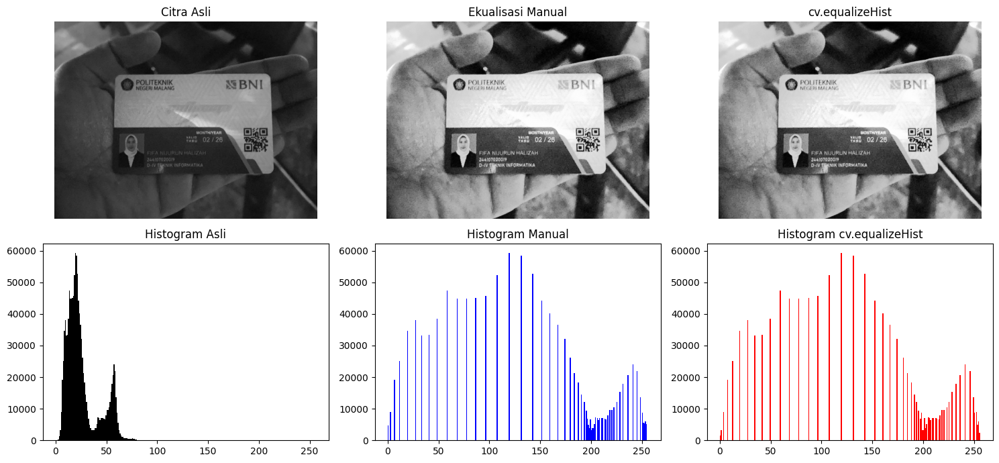

In [ ]:
# Ekualisasi Manual
hist, _ = np.histogram(img.flatten(), 256, [0, 256])
cdf = hist.cumsum()
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min()) * 255 / ((img.shape[0] * img.shape[1]) - cdf_m.min())
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')
img_manual = cdf_final[img]

# Ekualisasi OpenCV
img_eq = cv.equalizeHist(img)

# Hitung PSNR
psnr_eq = cv.PSNR(img, img_eq)
print(f"Nilai PSNR (Citra Asli vs cv.equalizeHist): {psnr_eq:.2f} dB")

# Plot Visualisasi
plt.figure(figsize=(15, 7))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img_manual, cmap='gray')
plt.title('Ekualisasi Manual')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(img_eq, cmap='gray')
plt.title('cv.equalizeHist')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.hist(img.ravel(), 256, [0, 256], color='black')
plt.title('Histogram Asli')

plt.subplot(2, 3, 5)
plt.hist(img_manual.ravel(), 256, [0, 256], color='blue')
plt.title('Histogram Manual')

plt.subplot(2, 3, 6)
plt.hist(img_eq.ravel(), 256, [0, 256], color='red')
plt.title('Histogram cv.equalizeHist')

plt.tight_layout()
plt.show()

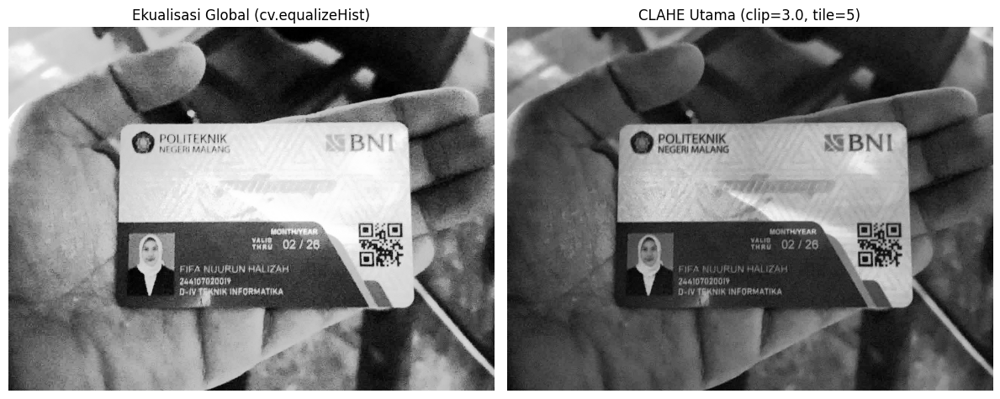

In [ ]:
# CLAHE Utama dengan parameter NIM (clipLimit=3.0, tileGridSize=(5,5))
clahe_main = cv.createCLAHE(clipLimit=clip_val, tileGridSize=(tile_val, tile_val))
img_clahe_main = clahe_main.apply(img)

# Tampilkan Perbandingan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_eq, cmap='gray')
plt.title('Ekualisasi Global (cv.equalizeHist)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_clahe_main, cmap='gray')
plt.title(f'CLAHE Utama (clip={clip_val}, tile={tile_val})')
plt.axis('off')

plt.tight_layout()
plt.show()

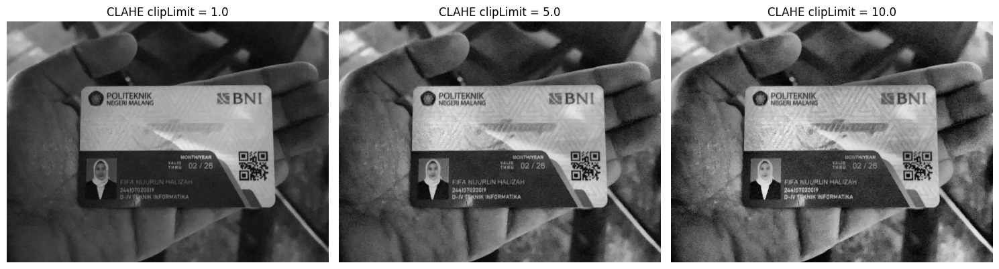

In [ ]:
# Percobaan 3 nilai clipLimit lain (misal: 1.0, 5.0, 10.0)
clip_limits = [1.0, 5.0, 10.0]
clahe_results = [cv.createCLAHE(clipLimit=c, tileGridSize=(tile_val, tile_val)).apply(img) for c in clip_limits]

# Tampilkan Hasil Variasi
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(clahe_results[0], cmap='gray')
plt.title(f'CLAHE clipLimit = {clip_limits[0]}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(clahe_results[1], cmap='gray')
plt.title(f'CLAHE clipLimit = {clip_limits[1]}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(clahe_results[2], cmap='gray')
plt.title(f'CLAHE clipLimit = {clip_limits[2]}')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg_dither(img_bgr, levels=2):
    # Buat salinan citra dengan tipe float32 untuk menghindari overflow/underflow
    img = img_bgr.copy().astype(np.float32)
    h, w, c = img.shape

    # Faktor skala untuk pembagian level kuantisasi
    factor = levels - 1

    for y in range(h):
        for x in range(w):
            for ch in range(c):
                old_val = img[y, x, ch]
                # Hitung nilai baru setelah kuantisasi
                new_val = np.round(old_val * factor / 255.0) * (255.0 / factor)
                img[y, x, ch] = new_val

                # Hitung error kuantisasi
                err = old_val - new_val

                # Distribusi error Floyd-Steinberg (7/16, 3/16, 5/16, 1/16)
                if x + 1 < w:
                    img[y, x + 1, ch] += err * 7 / 16
                if y + 1 < h:
                    if x > 0:
                        img[y + 1, x - 1, ch] += err * 3 / 16
                    img[y + 1, x, ch] += err * 5 / 16
                    if x + 1 < w:
                        img[y + 1, x + 1, ch] += err * 1 / 16

    # Potong nilai ke rentang valid [0, 255] dan konversi kembali ke uint8
    return np.clip(img, 0, 255).astype(np.uint8)

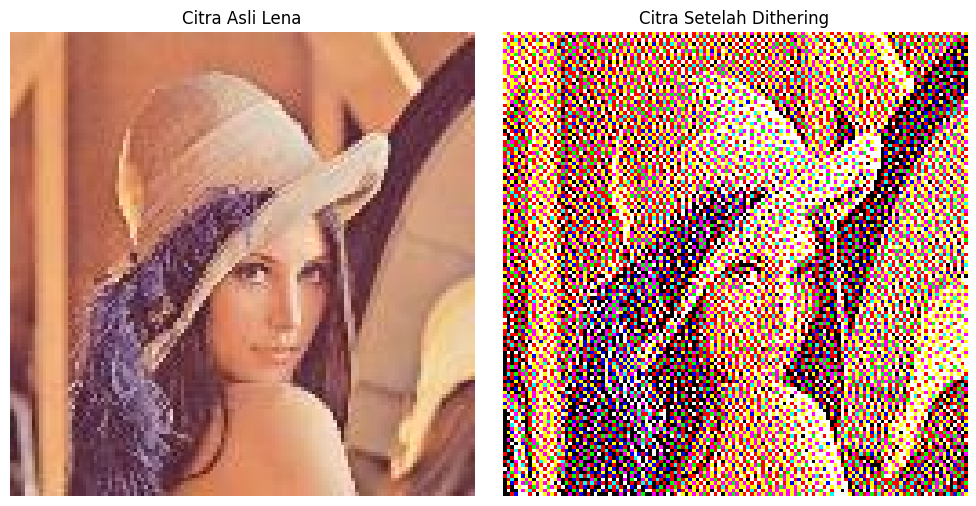

In [ ]:
# 1. Baca citra Lena
img_lena = cv.imread('lena.jpg')

# 2. Terapkan Dithering Floyd-Steinberg (2 level per kanal)
dither_lena = floyd_steinberg_dither(img_lena, levels=2)

# 3. Tampilkan Hasil Tahap 1
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_lena, cv.COLOR_BGR2RGB))
plt.title('Citra Asli Lena')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(dither_lena, cv.COLOR_BGR2RGB))
plt.title('Citra Setelah Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

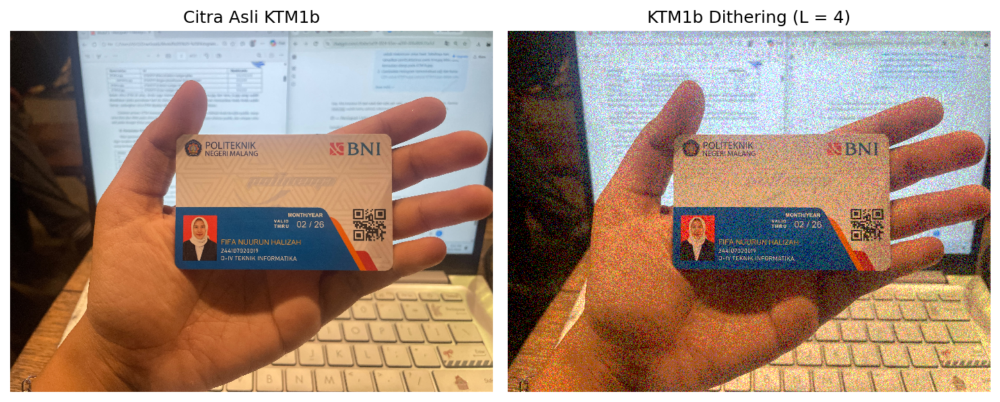

In [ ]:
# PARAM['L'] sesuai NIM kamu
L_val = 4

# 1. Baca citra KTM1b.jpg
img_ktm = cv.imread('KTM1b.jpg')

# 2. Terapkan Dithering Floyd-Steinberg (L level)
dither_ktm = floyd_steinberg_dither(img_ktm, levels=L_val)

# 3. Tampilkan Hasil Tahap 2
plt.figure(figsize=(10, 5), dpi=150)

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_ktm, cv.COLOR_BGR2RGB), interpolation='none')
plt.title('Citra Asli KTM1b')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(dither_ktm, cv.COLOR_BGR2RGB), interpolation='none')
plt.title(f'KTM1b Dithering (L = {L_val})')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

NIM = "244107020019"

def floyd_steinberg_gray(img_gray, levels=2):
    img = img_gray.copy().astype(np.float32)
    h, w = img.shape
    factor = levels - 1

    for y in range(h):
        for x in range(w):
            old_val = img[y, x]
            new_val = np.round(old_val * factor / 255.0) * (255.0 / factor)
            img[y, x] = new_val
            err = old_val - new_val

            if x + 1 < w:
                img[y, x + 1] += err * 7 / 16
            if y + 1 < h:
                if x > 0:
                    img[y + 1, x - 1] += err * 3 / 16
                img[y + 1, x] += err * 5 / 16
                if x + 1 < w:
                    img[y + 1, x + 1] += err * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

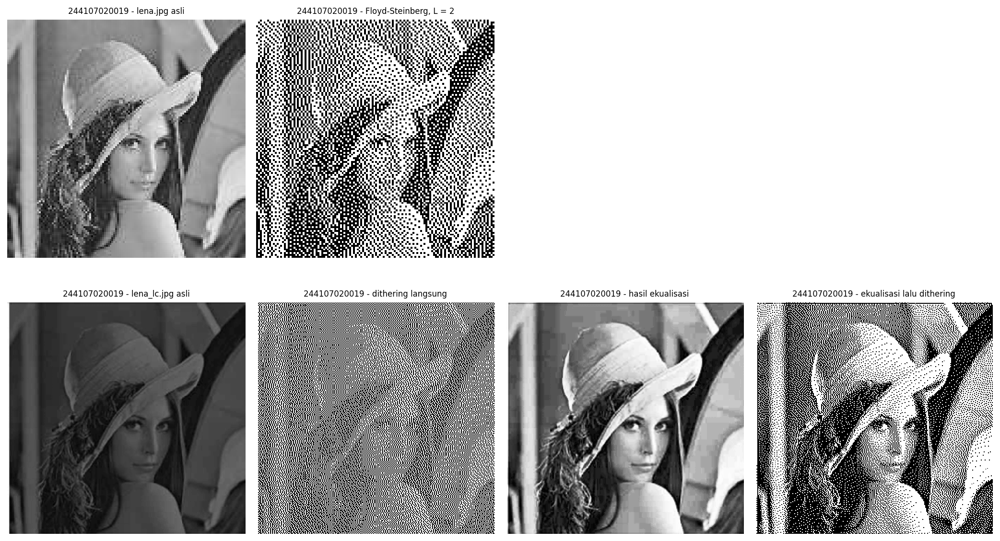

In [ ]:
# --- TAHAP LENA (Sesuai Layout Gambar) ---
img_lena = cv.imread('lena.jpg', cv.IMREAD_GRAYSCALE)
img_lena_lc = cv.imread('lena_lc.jpg', cv.IMREAD_GRAYSCALE)

# Dithering langsung pada lena.jpg
dither_lena = floyd_steinberg_gray(img_lena, levels=2)

# Dithering langsung vs Ekualisasi pada lena_lc.jpg
dither_lc_direct = floyd_steinberg_gray(img_lena_lc, levels=2)
eq_lc = cv.equalizeHist(img_lena_lc)
dither_lc_eq = floyd_steinberg_gray(eq_lc, levels=2)

# Plotting sesuai gambar contoh
plt.figure(figsize=(14, 8), dpi=150)

# Baris 1: lena.jpg
plt.subplot(2, 4, 1)
plt.imshow(img_lena, cmap='gray', interpolation='none')
plt.title(f'{NIM} - lena.jpg asli', fontsize=8)
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(dither_lena, cmap='gray', interpolation='none')
plt.title(f'{NIM} - Floyd-Steinberg, L = 2', fontsize=8)
plt.axis('off')

# Baris 2: lena_lc.jpg
plt.subplot(2, 4, 5)
plt.imshow(img_lena_lc, cmap='gray', interpolation='none')
plt.title(f'{NIM} - lena_lc.jpg asli', fontsize=8)
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(dither_lc_direct, cmap='gray', interpolation='none')
plt.title(f'{NIM} - dithering langsung', fontsize=8)
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(eq_lc, cmap='gray', interpolation='none')
plt.title(f'{NIM} - hasil ekualisasi', fontsize=8)
plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(dither_lc_eq, cmap='gray', interpolation='none')
plt.title(f'{NIM} - ekualisasi lalu dithering', fontsize=8)
plt.axis('off')

plt.tight_layout()
plt.show()

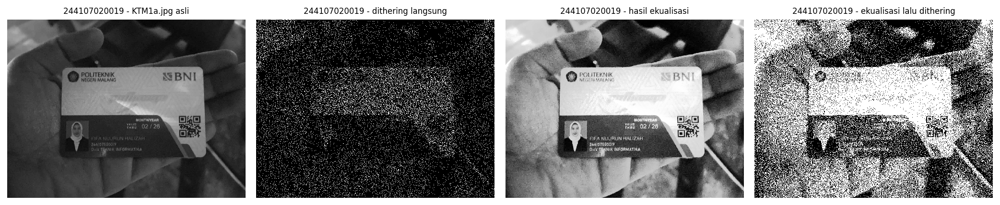

In [ ]:
# --- TAHAP KTM1a ---
img_ktm = cv.imread('KTM1a.jpg', cv.IMREAD_GRAYSCALE)

# Dithering langsung
dither_ktm_direct = floyd_steinberg_gray(img_ktm, levels=2)

# Ekualisasi lalu Dithering
eq_ktm = cv.equalizeHist(img_ktm)
dither_ktm_eq = floyd_steinberg_gray(eq_ktm, levels=2)

# Plotting Hasil KTM
plt.figure(figsize=(14, 4), dpi=150)

plt.subplot(1, 4, 1)
plt.imshow(img_ktm, cmap='gray', interpolation='none')
plt.title(f'{NIM} - KTM1a.jpg asli', fontsize=8)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(dither_ktm_direct, cmap='gray', interpolation='none')
plt.title(f'{NIM} - dithering langsung', fontsize=8)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(eq_ktm, cmap='gray', interpolation='none')
plt.title(f'{NIM} - hasil ekualisasi', fontsize=8)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(dither_ktm_eq, cmap='gray', interpolation='none')
plt.title(f'{NIM} - ekualisasi lalu dithering', fontsize=8)
plt.axis('off')

plt.tight_layout()
plt.show()